# 🌾 Crop Recommendation & Yield Prediction System
### End-to-End ML Pipeline | India Agriculture Dataset

**Objective:** Given a user's location (state), automatically estimate soil and climate parameters,  
recommend the best crops, and predict the expected yield per hectare.

**Pipeline:**
```
State Input → Soil/Weather Lookup → Crop Recommender (RF Classifier) → Yield Predictor (XGBoost Regressor)
```


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             r2_score, mean_squared_error, mean_absolute_error)
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


## 2. Crop Recommendation Dataset
> Features: N, P, K (soil nutrients), temperature, humidity, pH, rainfall → Target: crop label

In [2]:
# Load dataset — update path if needed
df = pd.read_csv("Crop_recommendation.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape: (2200, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
print("\n=== Missing Values ===")
print(df.isnull().sum())



=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [6]:
print("\n=== Class Distribution ===")
print(df['label'].value_counts())


=== Class Distribution ===
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [7]:
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 3. Exploratory Data Analysis

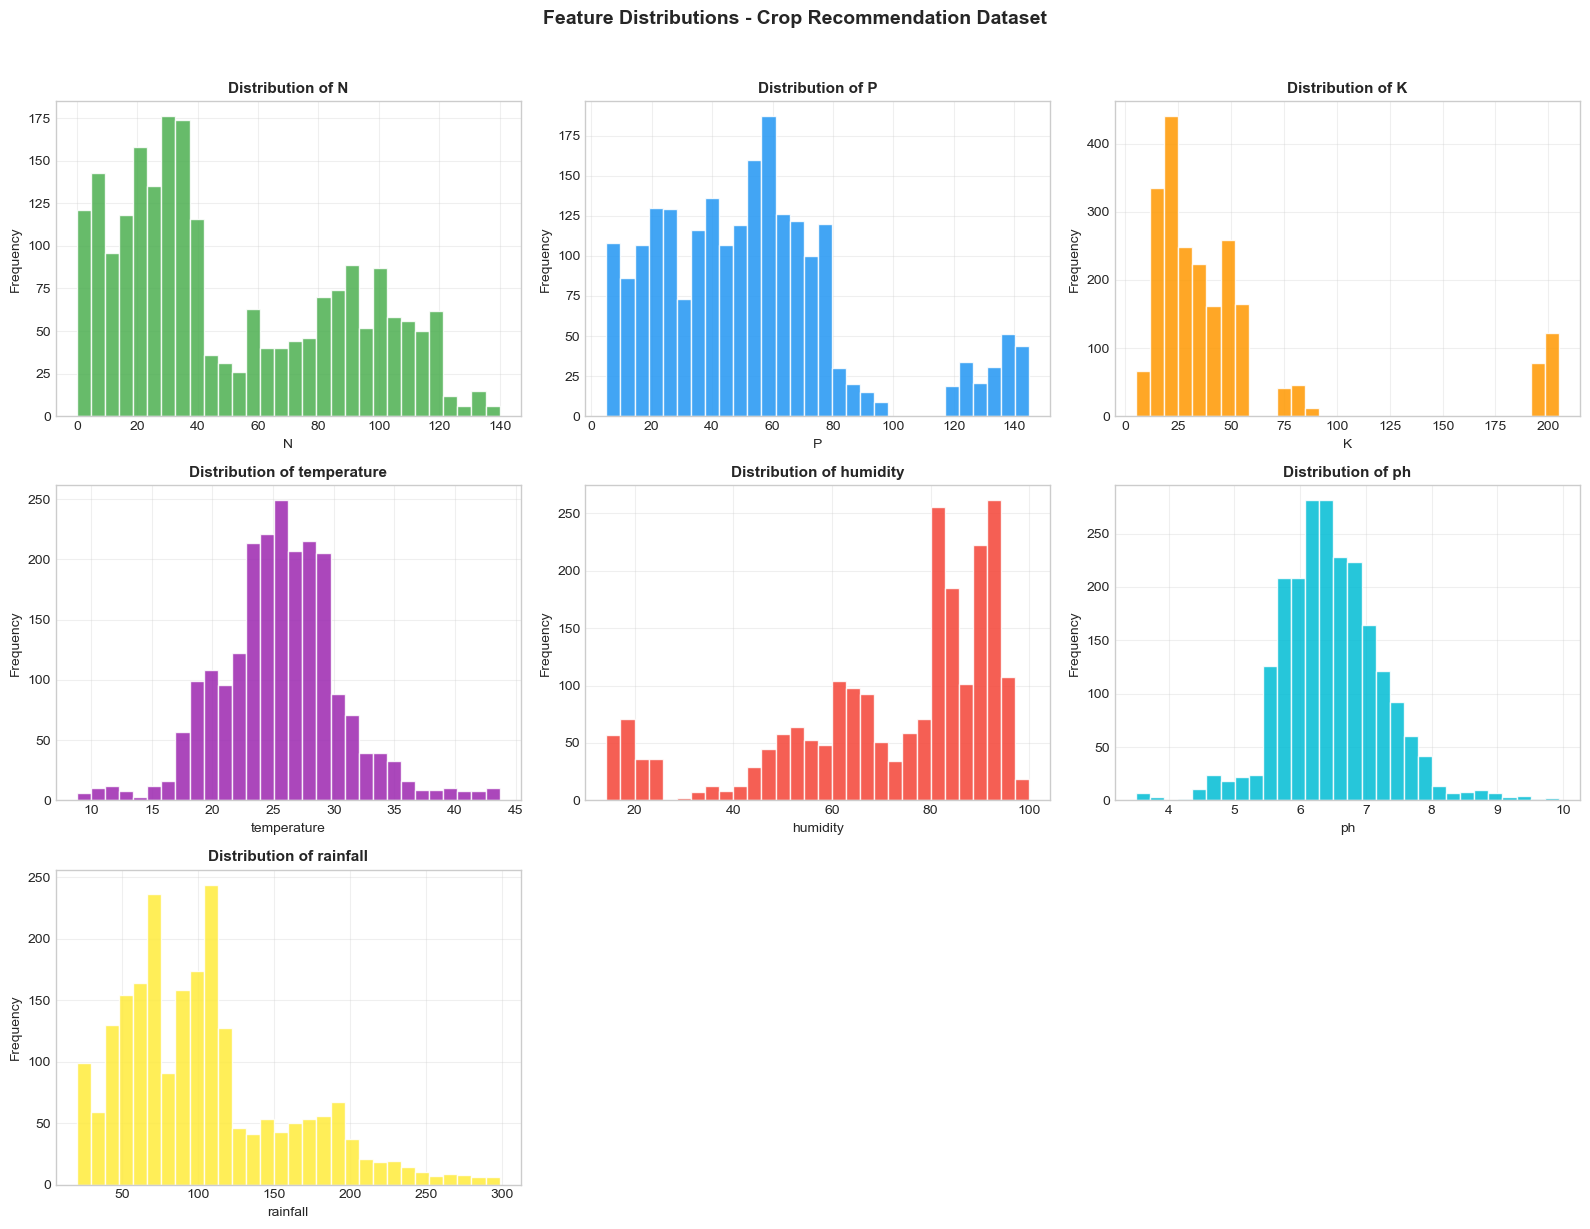

In [8]:
# Feature distributions
numeric_cols = df.select_dtypes(include='number').columns
colors = ["#4CAF50","#2196F3","#FF9800","#9C27B0","#F44336","#00BCD4","#FFEB3B"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions - Crop Recommendation Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

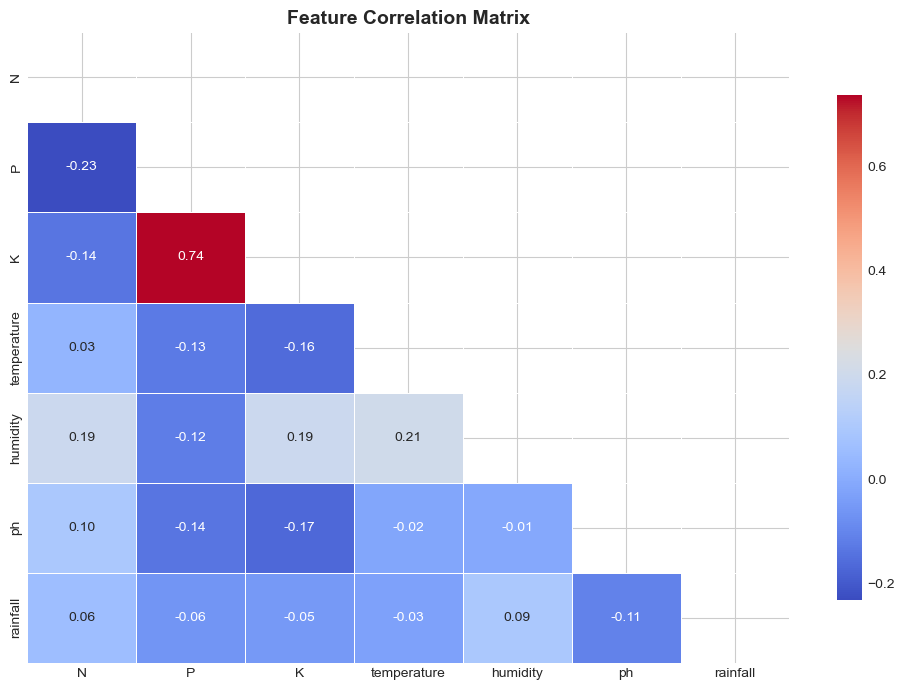

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Crop-wise average nutrient requirements — useful for domain understanding
crop_avg = df.groupby('label')[['N','P','K','temperature','humidity','ph','rainfall']].mean().round(1)
print("Crop-wise average feature values:")
crop_avg

Crop-wise average feature values:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.8,134.2,199.9,22.6,92.3,5.9,112.7
banana,100.2,82.0,50.0,27.4,80.4,6.0,104.6
blackgram,40.0,67.5,19.2,30.0,65.1,7.1,67.9
chickpea,40.1,67.8,79.9,18.9,16.9,7.3,80.1
coconut,22.0,16.9,30.6,27.4,94.8,6.0,175.7
coffee,101.2,28.7,29.9,25.5,58.9,6.8,158.1
cotton,117.8,46.2,19.6,24.0,79.8,6.9,80.4
grapes,23.2,132.5,200.1,23.8,81.9,6.0,69.6
jute,78.4,46.9,40.0,25.0,79.6,6.7,174.8


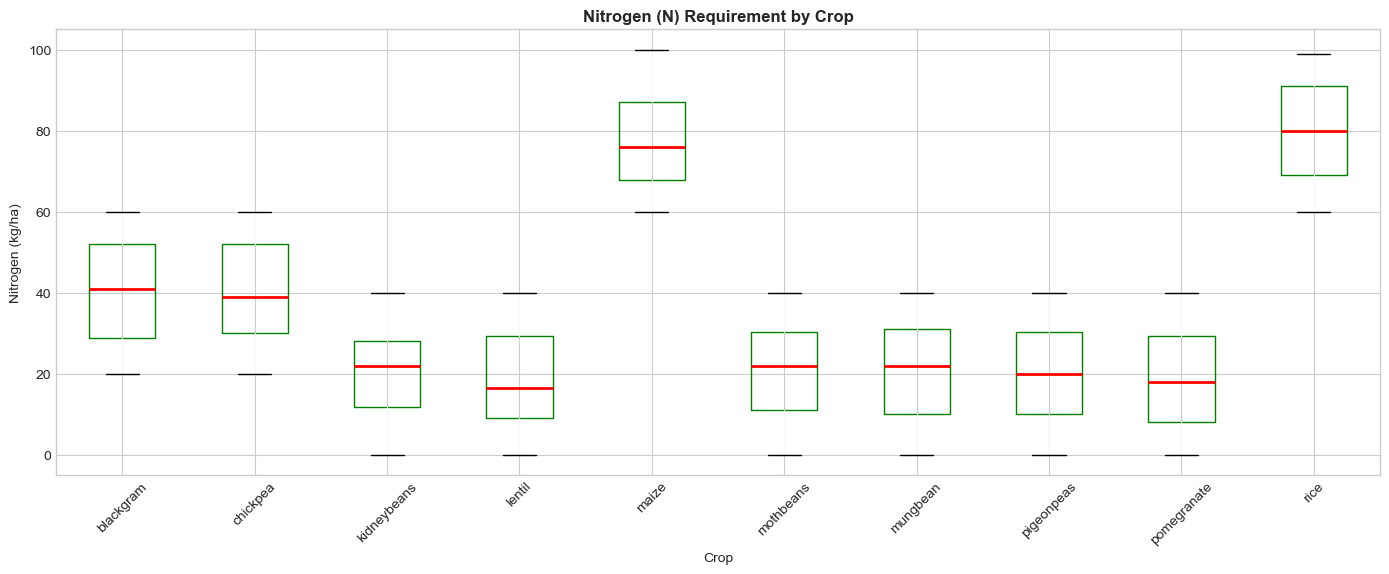

In [11]:
# Boxplot: N requirement by crop (top crops)
top_crops = df['label'].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(14, 6))
df[df['label'].isin(top_crops)].boxplot(column='N', by='label', ax=ax,
    boxprops=dict(color='green'), medianprops=dict(color='red', linewidth=2))
ax.set_title('Nitrogen (N) Requirement by Crop', fontweight='bold')
ax.set_xlabel('Crop')
ax.set_ylabel('Nitrogen (kg/ha)')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
X = df.drop('label', axis=1)
y = df['label']


In [13]:

# Label encode target
le_crop_rec = LabelEncoder()
y_encoded = le_crop_rec.fit_transform(y)



In [14]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Classes:", list(le_crop_rec.classes_))
print("Feature columns:", list(X.columns))


Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
Feature columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (1540, 7), Test size: (660, 7)


## 5. Model Training — Crop Recommender

In [16]:
# Random Forest Classifier with cross-validation
crop_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)


crop_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
# Evaluation
y_pred = crop_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\n" + classification_report(y_test, y_pred,
      target_names=le_crop_rec.classes_))

Test Accuracy: 0.9939 (99.39%)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      0.97      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        30
      grapes       1.00      1.00      1.00        30
        jute       0.94      1.00      0.97        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       1.00      0.97      0.98        30
       maize       0.97      1.00      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       0.97      1.00      0.98        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00      

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 97.88%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       0.97      1.00      0.98        30
           3       1.00      1.00      1.00        30
           4       0.97      1.00      0.98        30
           5       1.00      1.00      1.00        30
           6       0.94      1.00      0.97        30
           7       1.00      1.00      1.00        30
           8       0.91      1.00      0.95        30
           9       0.94      1.00      0.97        30
          10       1.00      0.97      0.98        30
          11       1.00      0.93      0.97        30
          12       0.97      1.00      0.98        30
          13       0.97      0.97      0.97        30
          14       1.00      1.00      1.00        30
          15       1.00      1.00      1.00        30
          16       1.00      0.87   

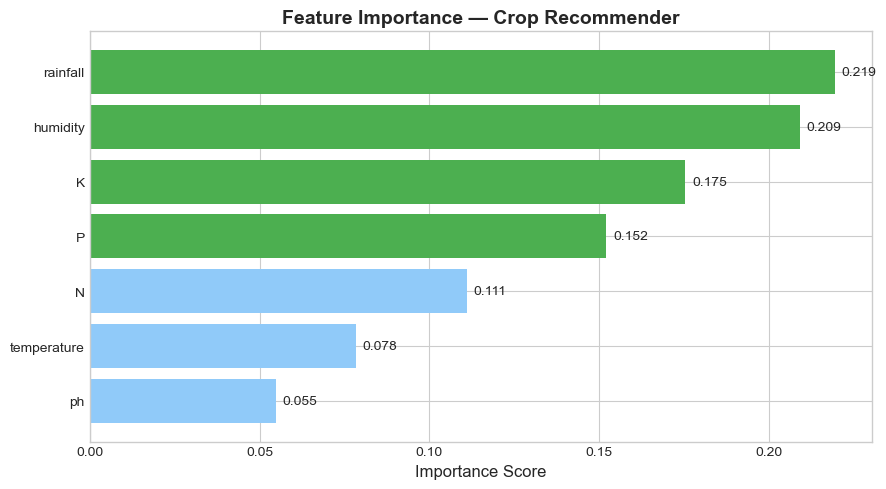

In [19]:
# Feature importance
importances = crop_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=['#4CAF50' if v > 0.15 else '#90CAF9' for v in feat_df['Importance']])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — Crop Recommender', fontsize=14, fontweight='bold')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance_crop.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Crop Recommendation Model Artifacts

In [20]:
joblib.dump(crop_model, 'models/crop_model.pkl')
joblib.dump(le_crop_rec, 'models/label_encoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(list(X.columns), 'models/feature_columns.pkl')
print("✅ Saved: crop_model.pkl, label_encoder.pkl, scaler.pkl, feature_columns.pkl")

✅ Saved: crop_model.pkl, label_encoder.pkl, scaler.pkl, feature_columns.pkl


## 7. Crop Yield Dataset
> Features: State, Crop, Season, Year, Area → Target: Yield (Production/Area)

In [21]:
yield_df = pd.read_csv("crop_production.csv")
print(f"Shape: {yield_df.shape}")
print(f"Columns: {list(yield_df.columns)}")


Shape: (246091, 7)
Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


In [22]:
yield_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [23]:
print("=== Dataset Info ===")
yield_df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [24]:
print("\n=== Missing Values ===")
print(yield_df.isnull().sum())


=== Missing Values ===
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [25]:
print("Unique States:", yield_df['State_Name'].nunique())
print("Unique Districts:", yield_df['District_Name'].nunique())
print("Unique Crops:", yield_df['Crop'].nunique())
print("Unique Seasons:", yield_df['Season'].nunique())
print("Year Range:", yield_df['Crop_Year'].min(), "→", yield_df['Crop_Year'].max())

Unique States: 33
Unique Districts: 646
Unique Crops: 124
Unique Seasons: 6
Year Range: 1997 → 2015


## 8. Feature Engineering & Cleaning

In [26]:
# Fill missing production with median
yield_df['Production'] = yield_df['Production'].fillna(yield_df['Production'].median())

# Remove zero area rows
yield_df = yield_df[yield_df['Area'] > 0].copy()
yield_df.dropna(inplace=True)

# Create target: Yield = Production / Area (tonnes/hectare)
yield_df['Yield'] = yield_df['Production'] / yield_df['Area']

# Remove outliers (top 1%)
q99 = yield_df['Yield'].quantile(0.99)
yield_df = yield_df[yield_df['Yield'] < q99]

print(f"Clean dataset shape: {yield_df.shape}")
print(f"Yield range: {yield_df['Yield'].min():.2f} → {yield_df['Yield'].max():.2f}")
yield_df.head()

Clean dataset shape: (243630, 8)
Yield range: 0.00 → 235.56


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


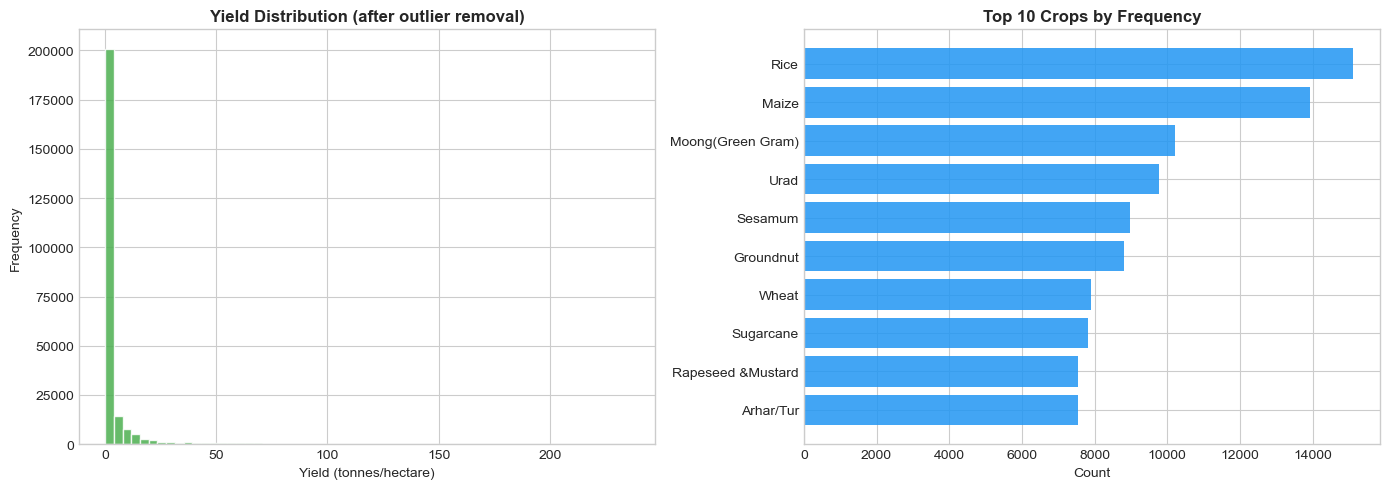

In [27]:
# EDA — Yield distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(yield_df['Yield'], bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Yield Distribution (after outlier removal)', fontweight='bold')
axes[0].set_xlabel('Yield (tonnes/hectare)')
axes[0].set_ylabel('Frequency')

# Top 10 crops by count
top10 = yield_df['Crop'].value_counts().head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1], color='#2196F3', alpha=0.85)
axes[1].set_title('Top 10 Crops by Frequency', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_yield.png', dpi=150, bbox_inches='tight')
plt.show()

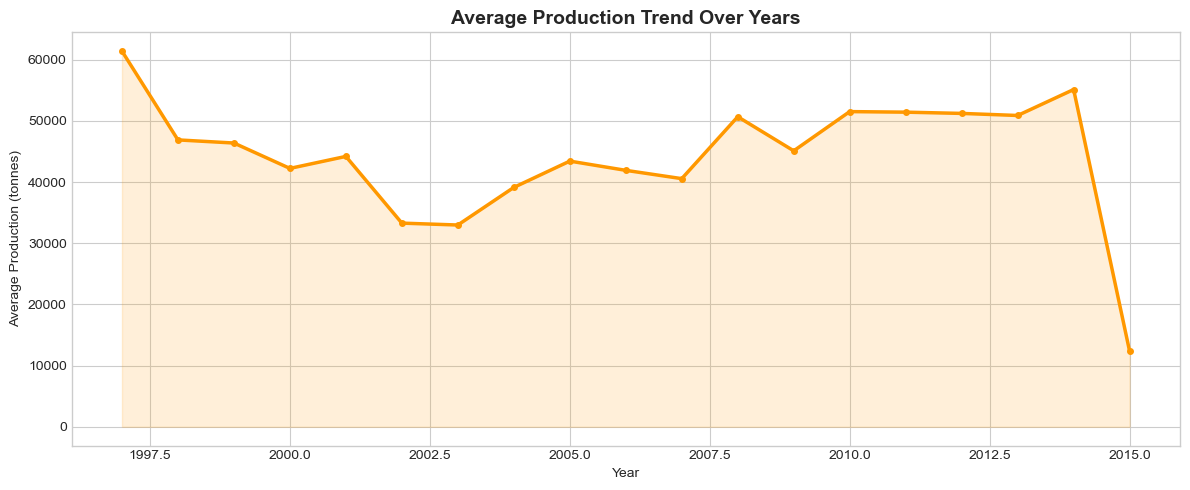

In [28]:
# Production trend over years
yearly = yield_df.groupby('Crop_Year')['Production'].mean()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly.index, yearly.values, color='#FF9800', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#FF9800')
ax.set_title('Average Production Trend Over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Production (tonnes)')
plt.tight_layout()
plt.savefig('eda_production_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Preprocessing — Yield Dataset

In [29]:
# Strip whitespace from Season column
yield_df['Season'] = yield_df['Season'].str.strip()

# Label encode categorical columns
le_state = LabelEncoder()
le_crop_yield = LabelEncoder()
le_season = LabelEncoder()

yield_df_enc = yield_df.copy()
yield_df_enc['State_Name'] = le_state.fit_transform(yield_df_enc['State_Name'])
yield_df_enc['Crop']       = le_crop_yield.fit_transform(yield_df_enc['Crop'])
yield_df_enc['Season']     = le_season.fit_transform(yield_df_enc['Season'])

print("States:", list(le_state.classes_))
print("\nSeasons:", list(le_season.classes_))



States: ['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Seasons: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']


In [30]:
# ---Mappings ---

# State Encoding
state_mapping = dict(zip(le_state.classes_, le_state.transform(le_state.classes_)))
print("=== State Encoding ===")
for state, code in state_mapping.items():
    print(f"  {state} : {code}")

# Crop Encoding
crop_mapping = dict(zip(le_crop_yield.classes_, le_crop_yield.transform(le_crop_yield.classes_)))
print("\n=== Crop Encoding ===")
for crop, code in crop_mapping.items():
    print(f"  {crop} : {code}")

# Season Encoding
season_mapping = dict(zip(le_season.classes_, le_season.transform(le_season.classes_)))
print("\n=== Season Encoding ===")
for season, code in season_mapping.items():
    print(f"  {season} : {code}")


=== State Encoding ===
  Andaman and Nicobar Islands : 0
  Andhra Pradesh : 1
  Arunachal Pradesh : 2
  Assam : 3
  Bihar : 4
  Chandigarh : 5
  Chhattisgarh : 6
  Dadra and Nagar Haveli : 7
  Goa : 8
  Gujarat : 9
  Haryana : 10
  Himachal Pradesh : 11
  Jammu and Kashmir  : 12
  Jharkhand : 13
  Karnataka : 14
  Kerala : 15
  Madhya Pradesh : 16
  Maharashtra : 17
  Manipur : 18
  Meghalaya : 19
  Mizoram : 20
  Nagaland : 21
  Odisha : 22
  Puducherry : 23
  Punjab : 24
  Rajasthan : 25
  Sikkim : 26
  Tamil Nadu : 27
  Telangana  : 28
  Tripura : 29
  Uttar Pradesh : 30
  Uttarakhand : 31
  West Bengal : 32

=== Crop Encoding ===
  Apple : 0
  Arcanut (Processed) : 1
  Arecanut : 2
  Arhar/Tur : 3
  Ash Gourd : 4
  Atcanut (Raw) : 5
  Bajra : 6
  Banana : 7
  Barley : 8
  Bean : 9
  Beans & Mutter(Vegetable) : 10
  Beet Root : 11
  Ber : 12
  Bhindi : 13
  Bitter Gourd : 14
  Black pepper : 15
  Blackgram : 16
  Bottle Gourd : 17
  Brinjal : 18
  Cabbage : 19
  Cardamom : 20
  Carr

In [31]:
X_yield = yield_df_enc[['State_Name', 'Crop', 'Crop_Year', 'Season', 'Area']]
y_yield = yield_df_enc['Yield']


In [32]:

X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yield, y_yield, test_size=0.30, random_state=42)

print(f"\nYield Train: {X_train_y.shape}, Test: {X_test_y.shape}")


Yield Train: (170541, 5), Test: (73089, 5)


## 10. Yield Prediction Models

In [33]:
# --- Model 1: Random Forest Regressor ---
rf_yield = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_yield.fit(X_train_y, y_train_y)
rf_pred = rf_yield.predict(X_test_y)
rf_r2   = r2_score(y_test_y, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_y, rf_pred))
rf_mae  = mean_absolute_error(y_test_y, rf_pred)

# Accuracy as percentage (based on R² Score)
rf_accuracy = max(0, rf_r2) * 100

print("=== Random Forest Regressor ===")
print(f"Accuracy : {rf_accuracy:.2f}%")
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"MAE      : {rf_mae:.4f}")

=== Random Forest Regressor ===
Accuracy : 84.40%
R² Score : 0.8440
RMSE     : 5.3015
MAE      : 1.1532


In [34]:
# --- Model 2: XGBoost Regressor ---
xgb_yield = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_yield.fit(X_train_y, y_train_y,
              eval_set=[(X_test_y, y_test_y)],
              verbose=False)

xgb_pred = xgb_yield.predict(X_test_y)
xgb_r2   = r2_score(y_test_y, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_y, xgb_pred))
xgb_mae  = mean_absolute_error(y_test_y, xgb_pred)

print("=== XGBoost Regressor ===")
print(f"R² Score : {xgb_r2:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")
print(f"MAE      : {xgb_mae:.4f}")

=== XGBoost Regressor ===
R² Score : 0.8396
RMSE     : 5.3761
MAE      : 1.5411


In [35]:
yield_df['Yield'] = yield_df['Production'] / yield_df['Area']

In [36]:
# Create Yield Category (Low / Medium / High)

yield_df['Yield_Category'] = pd.qcut(
    yield_df['Yield'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(yield_df[['Yield','Yield_Category']].head())

      Yield Yield_Category
0  1.594896         Medium
1  0.500000            Low
2  3.147059           High
3  3.642045           High
4  0.229167            Low


In [37]:
# --- Model 2: XGBoost Regressor ---
xgb_yield = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_yield.fit(X_train_y, y_train_y,
              eval_set=[(X_test_y, y_test_y)],
              verbose=False)

xgb_pred = xgb_yield.predict(X_test_y)
xgb_r2   = r2_score(y_test_y, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_y, xgb_pred))
xgb_mae  = mean_absolute_error(y_test_y, xgb_pred)

# Accuracy as percentage (based on R² Score)
xgb_accuracy = max(0, xgb_r2) * 100

print("=== XGBoost Regressor ===")
print(f"Accuracy : {xgb_accuracy:.2f}%")
print(f"R² Score : {xgb_r2:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")
print(f"MAE      : {xgb_mae:.4f}")

=== XGBoost Regressor ===
Accuracy : 83.96%
R² Score : 0.8396
RMSE     : 5.3761
MAE      : 1.5411


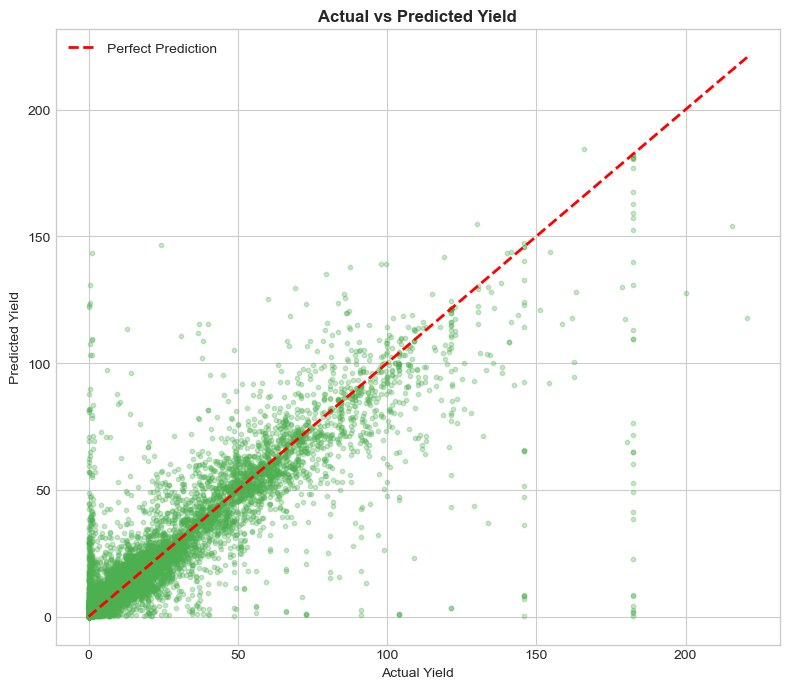

In [38]:
# Actual vs Predicted plot for best model
best_pred = xgb_pred if xgb_r2 > rf_r2 else rf_pred

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_y, best_pred, alpha=0.3, s=10, color='#4CAF50')
lims = [min(y_test_y.min(), best_pred.min()), max(y_test_y.max(), best_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')
ax.set_title('Actual vs Predicted Yield', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Create Yield Category (Low / Medium / High)

yield_df['Yield_Category'] = pd.qcut(
    yield_df['Yield'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(yield_df[['Yield','Yield_Category']].head())

      Yield Yield_Category
0  1.594896         Medium
1  0.500000            Low
2  3.147059           High
3  3.642045           High
4  0.229167            Low


In [42]:
from sklearn.preprocessing import LabelEncoder

le_yield_cat = LabelEncoder()
yield_df_enc['Yield_Category'] = le_yield_cat.fit_transform(
    yield_df['Yield_Category']
)

In [43]:
# USE ENCODED DATAFRAME

X_yield_cls = yield_df_enc[
    ['State_Name','Crop','Crop_Year','Season','Area']
]

y_yield_cls = yield_df_enc['Yield_Category']

In [44]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_yield_cls,
    y_yield_cls,
    test_size=0.3,
    random_state=42,
    stratify=y_yield_cls
)

In [45]:
print(X_train_c.dtypes)

State_Name      int64
Crop            int64
Crop_Year       int64
Season          int64
Area          float64
dtype: object


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

yield_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

yield_classifier.fit(X_train_c, y_train_c)

y_pred_c = yield_classifier.predict(X_test_c)

print("Yield Category Accuracy:",
      accuracy_score(y_test_c, y_pred_c)*100)

print(classification_report(y_test_c, y_pred_c))

# FIX: Ensure only numeric features are used
X_train_c = X_train_c.drop(columns=['State_Name'], errors='ignore')
X_test_c = X_test_c.drop(columns=['State_Name'], errors='ignore')

Yield Category Accuracy: 79.61663177769569
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     24363
           1       0.80      0.81      0.81     24736
           2       0.71      0.74      0.73     23990

    accuracy                           0.80     73089
   macro avg       0.80      0.80      0.80     73089
weighted avg       0.80      0.80      0.80     73089



In [47]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test)

# Evaluation
lr_accuracy  = accuracy_score(y_test, y_pred_lr) * 100
lr_precision = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_recall    = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1        = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print("=== Logistic Regression ===")
print(f"Accuracy  : {lr_accuracy:.2f}%")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

# Predict a single sample
sample = [[90, 42, 43, 20.87, 82.00, 6.50, 202.93]]
print(f"\nPredicted Yield Category: {log_reg.predict(sample)[0]}")

=== Logistic Regression ===
Accuracy  : 97.27%
Precision : 0.9735
Recall    : 0.9727
F1 Score  : 0.9725

Predicted Yield Category: 20


## 11. Save Yield Model Artifacts

In [52]:
# Save best yield model
best_yield_model = xgb_yield if xgb_r2 > rf_r2 else rf_yield
joblib.dump(best_yield_model, 'models/yield_model.pkl')

# Save encoders
joblib.dump(le_state,      'models/le_state.pkl')
joblib.dump(le_crop_yield, 'models/le_crop_yield.pkl')
joblib.dump(le_season,     'models/le_season.pkl')

# Decide best yield model name (FIX)
best_model_name = "XGBoost" if xgb_r2 > rf_r2 else "RandomForest"

# Save metadata (needed by Streamlit app)
import json
meta = {
    'states':         list(le_state.classes_),
    'crops_yield':    list(le_crop_yield.classes_),
    'seasons':        list(le_season.classes_),
    'crops_rec':      list(le_crop_rec.classes_),
    'best_r2':        round(xgb_r2 if xgb_r2 > rf_r2 else rf_r2, 4),
    'yield_model':    best_model_name,
}
with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ Saved all model artifacts:")
print("  models/yield_model.pkl")
print("  models/le_state.pkl")
print("  models/le_crop_yield.pkl")
print("  models/le_season.pkl")
print("  models/metadata.json")

✅ Saved all model artifacts:
  models/yield_model.pkl
  models/le_state.pkl
  models/le_crop_yield.pkl
  models/le_season.pkl
  models/metadata.json


## 12. End-to-End Pipeline Test
Simulate what the Streamlit app will do

In [49]:
# Simulate user input: State = Maharashtra, Season = Kharif, Area = 5 ha, Year = 2024
import sys
sys.path.append('.')
from utils.lookup_data import get_state_data

state_name = "Maharashtra"
season_input = "Kharif"
area_ha = 5
crop_year = 2024

# Step 1: Get soil/weather from lookup
env = get_state_data(state_name)
print(f"🌍 State: {state_name}")
print(f"  Soil: N={env['N']}, P={env['P']}, K={env['K']}, pH={env['ph']}")
print(f"  Weather: Temp={env['temperature']}°C, Humidity={env['humidity']}%, Rainfall={env['rainfall']}mm")

# Step 2: Predict top crops
feature_cols = joblib.load('models/feature_columns.pkl')
input_rec = pd.DataFrame([[env['N'], env['P'], env['K'],
                            env['temperature'], env['humidity'],
                            env['ph'], env['rainfall']]],
                          columns=feature_cols)
input_scaled = scaler.transform(input_rec)

probs = crop_model.predict_proba(input_scaled)[0]
top3_idx = np.argsort(probs)[::-1][:3]
top3_crops = le_crop_rec.inverse_transform(top3_idx)
top3_probs = probs[top3_idx]

print(f"\n🌱 Top 3 Recommended Crops:")
for crop, prob in zip(top3_crops, top3_probs):
    print(f"  {crop}: {prob*100:.1f}% suitability")

# Step 3: Predict yield for each recommended crop
feature_cols_loaded = joblib.load('models/feature_columns.pkl')

print(f"\n📊 Yield Predictions:")
for crop in top3_crops:
    if crop in le_crop_yield.classes_:
        crop_enc   = le_crop_yield.transform([crop])[0]
        season_enc = le_season.transform([season_input.strip()])[0] if season_input.strip() in le_season.classes_ else 0
        state_enc  = le_state.transform([state_name])[0] if state_name in le_state.classes_ else 0
        
        inp = pd.DataFrame([[state_enc, crop_enc, crop_year, season_enc, area_ha]],
                           columns=['State_Name','Crop','Crop_Year','Season','Area'])
        yld = best_yield_model.predict(inp)[0]
        print(f"  {crop}: {yld:.2f} tonnes/hectare → {yld*area_ha:.2f} tonnes total")
    else:
        print(f"  {crop}: yield data not available in dataset")

# FIX: Define best_model_name
best_model_name = 'XGBoost' if xgb_r2 > rf_r2 else 'RandomForest'

🌍 State: Maharashtra
  Soil: N=268, P=54, K=208, pH=7.1
  Weather: Temp=28.5°C, Humidity=66%, Rainfall=1177mm

🌱 Top 3 Recommended Crops:
  coffee: 32.0% suitability
  grapes: 15.0% suitability
  apple: 11.0% suitability

📊 Yield Predictions:
  coffee: yield data not available in dataset
  grapes: yield data not available in dataset
  apple: yield data not available in dataset
